# Solemne 1

**Diego Muñoz Barra — 21239832-2**

Análisis de señales con ThinkDSP.

## Librerías a utilizar

In [4]:
from __future__ import print_function, division
%matplotlib inline

import sys
from pathlib import Path
import matplotlib.pyplot as plt

# El notebook puede ejecutarse desde la carpeta Solemne1 o desde la carpeta principal.
sys.path.extend(['.', '..'])
import thinkdsp

base = Path('.')
if not (base / 'mystery.wav').exists():
    base = base / 'Solemne1'

---
## Pregunta 1

La señal `mystery.wav` contiene un conjunto de señales en secciones. Se deben separar y caracterizar.

### Solución

Primero, cargaremos la señal para saber su duración, frecuencia de muestreo y sus posibles intervalos.

In [20]:
mystery = thinkdsp.read_wave(str(base / 'mystery.wav'))
mystery.normalize()
print('Frecuencia de muestreo:', mystery.framerate, 'Hz')
print('Duración:', round(mystery.duration, 3), 's')
mystery.make_audio()

Frecuencia de muestreo: 11025 Hz
Duración: 3.0 s


El espectrograma permite distinguir las secciones y observar qué frecuencias existen en cada instante. Gracias a esto, podemos saber que difiere la señal en distintos intervalos, en este caso entre 0-1, 1-2 y 2-3 segundos.

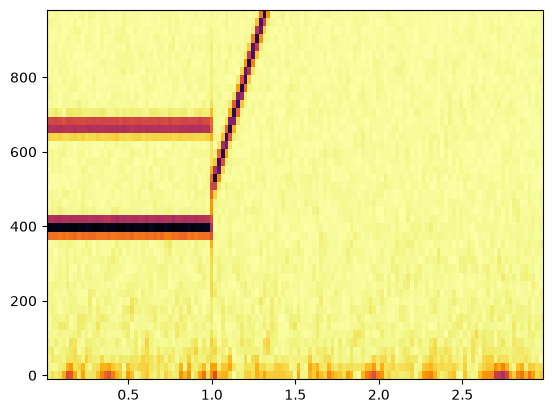

In [31]:
mystery.make_spectrogram(500).plot(high=1000)

Text(0.5, 1.0, 'Espectrograma de mystery.wav')

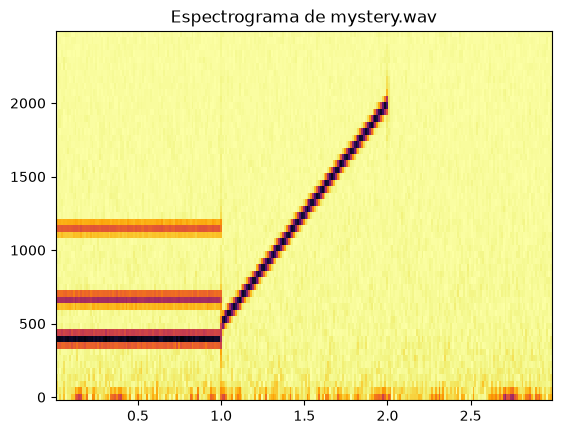

In [29]:
#spectrogram = wave.make_spectrogram(512)
#spectrogram.plot(high=2000)

mystery.make_spectrogram(250).plot(high=2500)
plt.title('Espectrograma de mystery.wav')

### Parte 1: 0–1 s

Se observan tres líneas horizontales en 400 Hz, 670 Hz y 1150 Hz. Como son frecuencias constantes y no aparecen sus armónicos, esta sección es una suma de tres señales cosenoidales (tonos puros).

Text(0.5, 1.0, 'Parte 1: espectro de los tonos constantes')

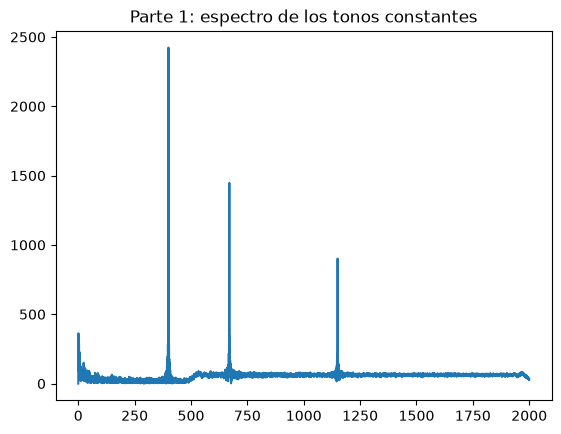

In [ ]:
part1 = mystery.segment()
spectrum1 = part1.make_spectrum()
spectrum1.plot(high=2000)

plt.title('Parte 1: espectro de los tonos constantes')

### Parte 2: 1–2 s

La línea inclinada del espectrograma muestra que la frecuencia aumenta con el tiempo. La señal comienza cerca de 400 Hz y termina cerca de 2000 Hz; por lo tanto, es un **chirp lineal**. Un único espectro no muestra bien este cambio, por eso el espectrograma es la herramienta principal en este caso.

Text(0.5, 1.0, 'Parte 2: oscilación al inicio y al final')

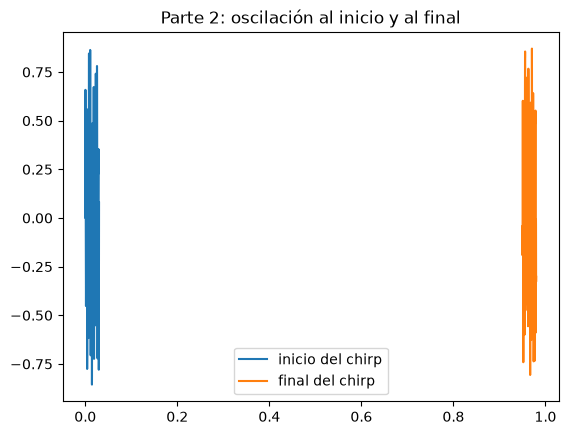

In [40]:
part2 = mystery.segment()
part2.segment(start=0, duration=0.03).plot(label='inicio del chirp')
part2.segment(start=0.95, duration=0.03).plot(label='final del chirp')

plt.legend()
plt.title('Parte 2: oscilación al inicio y al final')

### Parte 3: 2–3 s

En esta parte no presenta picos armónicos definidos, sino energía distribuida en muchas frecuencias. En una gráfica log-log, la pendiente del espectro de potencia es cercana a -1; esto corresponde a potencia proporcional a 1/f, que caracteriza al **ruido rosa**.

Pendiente estimada: -1.02


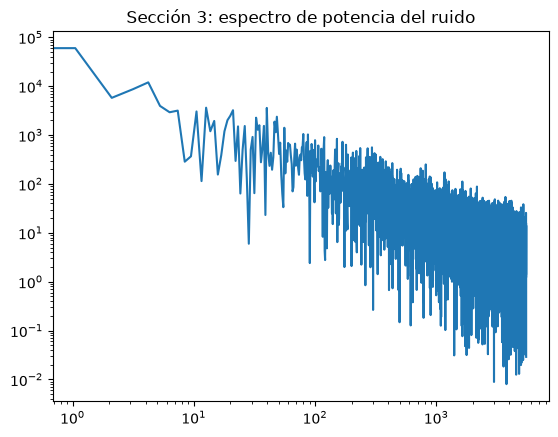

In [ ]:
part3 = mystery.segment(start=2, duration=0.95)
spectrum3 = part3.make_spectrum()
spectrum3.plot_power()
plt.xscale('log')
plt.yscale('log')
plt.title('Parte 3: espectro de potencia del ruido')

ajuste = spectrum3.estimate_slope()
print('Pendiente estimada:', round(ajuste.slope, 2))

**Conclusión pregunta 1:**

- De 0 a 1 s: suma de tres tonos cosenoidales de **400 Hz, 670 Hz y 1150 Hz**.
- De 1 a 2 s: **chirp lineal** que aumenta aproximadamente de **400 Hz a 2000 Hz**.
- De 2 a 3 s: **ruido rosa**, pues su potencia decae aproximadamente como $1/f$.

---
## Pregunta 2

La señal `pregunta.wav` contiene tres secciones. Se debe identificar el tipo de señal presente en cada una y justificar la respuesta.

### Solución

Cargamos la señal. Dura 1.5 s, de modo que cada sección dura aproximadamente 0.5 s.

In [18]:
pregunta = thinkdsp.read_wave(str(base / 'pregunta.wav'))
pregunta.normalize()
print('Frecuencia de muestreo:', pregunta.framerate, 'Hz')
print('Duración:', pregunta.duration, 's')
pregunta.make_audio()

Frecuencia de muestreo: 10000 Hz
Duración: 1.5 s


El espectrograma confirma que hay tres tramos de aproximadamente medio segundo.

Text(0.5, 1.0, 'Espectrograma de pregunta.wav')

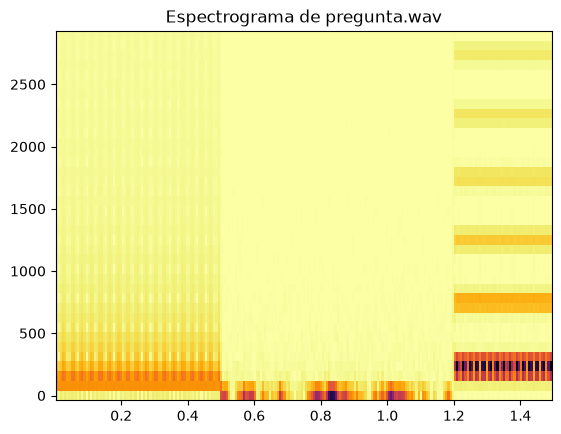

In [11]:
pregunta.make_spectrogram(128).plot(high=3000)
plt.title('Espectrograma de pregunta.wav')

### Parte 1: 0–0.5 s

El espectro tiene una fundamental de 120 Hz y armónicos en todos sus múltiplos: 240, 360, 480 Hz, etc. Por lo tanto, la presencia de armónicos pares e impares con amplitud decreciente corresponde a una **onda diente de sierra de 120 Hz**.

Text(0.5, 1.0, 'Parte 1: espectro de la diente de sierra')

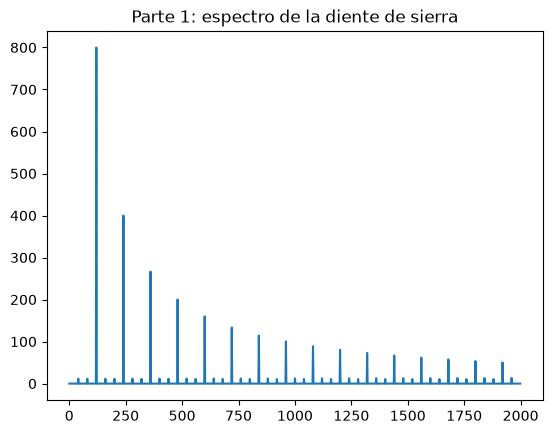

In [22]:
wave1 = pregunta.segment(start=0, duration=0.5)
wave1.make_spectrum().plot(high=2000)
plt.title('Parte 1: espectro de la diente de sierra')

### Parte 2: 0.5–1 s

No se observan picos periódicos; se trata de ruido. La mayor parte de su potencia está en bajas frecuencias y la pendiente log-log es cercana a -2. Por ello es **ruido browniano** o ruido rojo, cuya potencia es aproximadamente proporcional a 1/f².

Pendiente estimada: -1.83


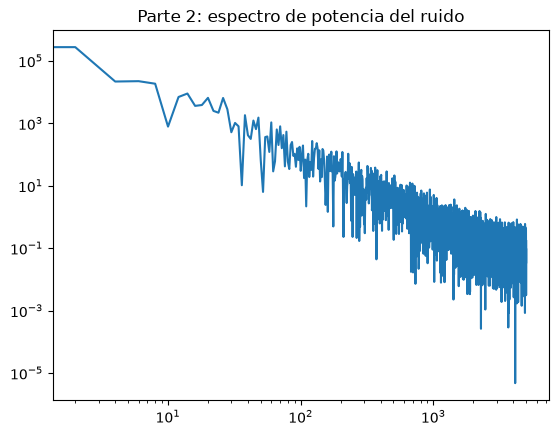

In [23]:
wave2 = pregunta.segment(start=0.5, duration=0.5)
spectrum_wave2 = wave2.make_spectrum()
spectrum_wave2.plot_power()
plt.xscale('log')
plt.yscale('log')
plt.title('Parte 2: espectro de potencia del ruido')

ajuste = spectrum_wave2.estimate_slope()
print('Pendiente estimada:', round(ajuste.slope, 2))

### Parte 3: 1–1.5 s

El espectro muestra un pico aislado en 200 Hz aprox y además, una fundamental en 250 Hz con los armónicos impares 750, 1250, 1750 Hz, etc. El pico aislado corresponde a una cosenoide, donde la serie de armónicos impares corresponde a una onda cuadrada. Esta parte corresponde a una mezcla de **cosenoide de 200 Hz** y **onda cuadrada de 250 Hz**.

Text(0.5, 1.0, 'Parte 3: espectro de la señal combinada')

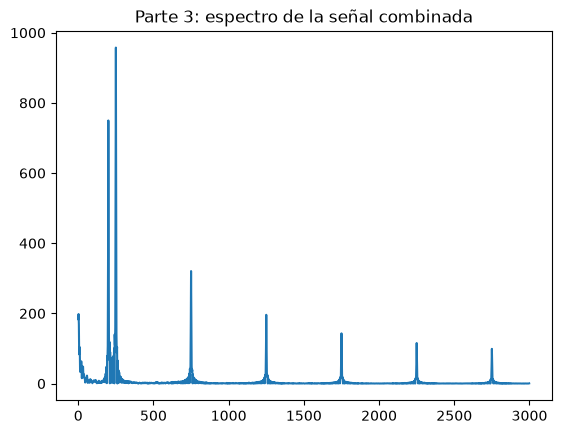

In [28]:
#wave3 = pregunta.segment()
wave3 = pregunta.segment(start=1, duration=0.5)
wave3.make_spectrum().plot(high=3000)
plt.title('Parte 3: espectro de la señal combinada')

**Conclusión pregunta 2:**

- De 0 a 0.5 s: **onda diente de sierra de 120 Hz**.
- De 0.5 a 1 s: **ruido browniano** (pendiente espectral cercana a -2).
- De 1 a 1.5 s: suma de una **cosenoide de 200 Hz** y una **onda cuadrada de 250 Hz**.